In this section we will build a simple K-Nearest Neighbors classifier . The Main idea for KNN is :
1. Predict the label of data point.
   
2. Looking at the k closest labeled data points.
   
3. Taking a majority vote.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data/telecom_churn_clean.csv')
df.head(10)

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
5,5,118,510,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,0
6,6,121,510,0,1,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0
7,7,147,415,1,0,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,0
8,8,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
9,9,141,415,1,1,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,0


In [3]:
df.columns

Index(['Unnamed: 0', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge', 'customer_service_calls',
       'churn'],
      dtype='object')

In [4]:
from sklearn.neighbors import KNeighborsClassifier

# Specifying X and Y values
X = df[['total_day_charge','total_eve_charge']].values
y = df['churn'].values

print(X.shape, y.shape)




(3333, 2) (3333,)


In [6]:
knn = KNeighborsClassifier(n_neighbors=15)

knn.fit(X, y)


KNeighborsClassifier(n_neighbors=15)

In [7]:
X_new = np.array([[56.8,17.5],
                  [24.4,24.1],
                  [50.1,10.9]])

print(X_new.shape)

(3, 2)


In [8]:
predictions = knn.predict(X_new)
print("Prediction :{}".format(predictions))

Prediction :[1 0 0]


## Measure Models performance

Accuracy is the most commons prediction that we can use. Some times its better to check performance by splitting data into train and test split.

In [14]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=21, stratify=y)

print(f"The shape of X_train is :{X_train.shape}")
print(f"The shape of X_test is :{X_test.shape}")
print(f"The shape of y_train is :{y_train.shape}")
print(f"The shape of y_test is :{y_test.shape}")

The shape of X_train is :(2333, 2)
The shape of X_test is :(1000, 2)
The shape of y_train is :(2333,)
The shape of y_test is :(1000,)


In [13]:
knn.fit(X_train, y_train)
print(knn.score(X_test, y_test))

0.879


### Modelling complexity and over/under fitting:

In [15]:
train_acc = {}
test_acc = {}
neighbors = np.arange(1,26)

for i in  neighbors:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    train_acc[i] = knn.score(X_train,y_train)
    test_acc[i] = knn.score(X_test, y_test)
 


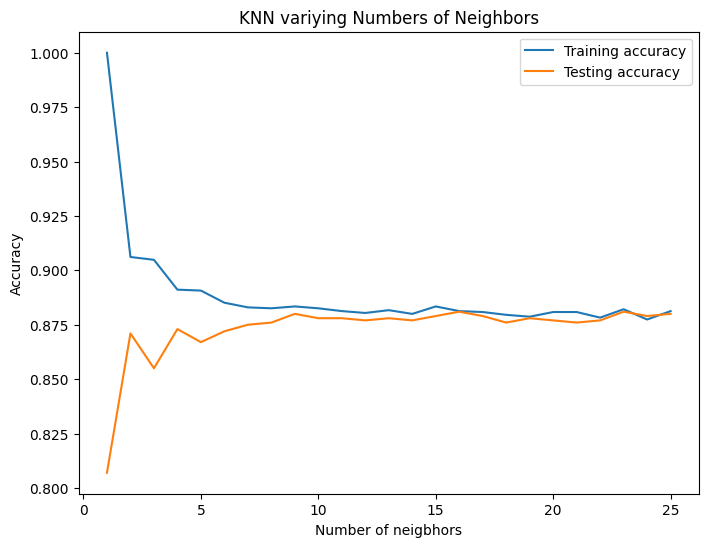

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.title("KNN variying Numbers of Neighbors")
plt.plot(neighbors, train_acc.values(), label="Training accuracy")
plt.plot(neighbors, test_acc.values(), label="Testing accuracy")
plt.legend()
plt.xlabel("Number of neigbhors")
plt.ylabel("Accuracy")
plt.show()